# GFTM high-WIDTH γ error: what causes it, given that resolution doesn't remove it? (Fusion_PhD-38e9.13)

In 38e9.12, raising NXGRID/NBASIS reduces the high-WIDTH γ error only a little. Four hypotheses (not exclusive):

- **H1** model at large |θ|: a wide basis puts weight where k_x = k_y ŝ θ is large (large k⊥ρ).
- **H2** mode identity: at large WIDTH the argmax jumps to another branch.
- **H3** geometry quadrature: a fixed node count over more 2π periods (38e9.12's inference; only argued indirectly).
- **H4** shared model physics: TGLF degrades the same way.

Phase 1, existing cubes only: (a) H2 branch continuity, (b) H1 weight beyond |θ| = π, (c) H4 TGLF control,
(d) the WIDTH-0.2 NBASIS/NXGRID split. GFTM is the subject; TGLF is the control (PLOTTING §7).
Population: GS2-KBM by the cube classifier (`mode_classification.indicators` on the GS2 `pyro_cube`), γ > 0.

In [1]:
from pathlib import Path
import os
import warnings
from multiprocessing import get_context
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import pyrokinetics
from pyrokinetics.pyroscan import PyroScanGKOutput
from pyrokinetics.diagnostics.extent import Extent
from pyrokinetics.diagnostics.field_line import FieldLine
from general_analysis import mode_classification as mc

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir())
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
load_dotenv(ROOT / "local.env", override=True)
warnings.filterwarnings("ignore")
print("pyrokinetics", pyrokinetics.__version__)

analysis_name = "gftm_highwidth_cause"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
project = "LATIN_HYPERCUBE"
cases = ["SPR-045", "M1"]
fields = ["phi", "apar"]
sections = {11: 17, 22: 28, 27: 33, 43: 49, 59: 65}   # NBASIS: NXGRID on the NXGRID-6 arm; NBASIS 22 is the wo_f05 scan
top_arm = [(33, 17), (64, 33), (64, 49), (64, 65)]     # (NBASIS, NXGRID) at the top of the valid window, 5 widths each
W_REF = np.sqrt(0.4 * 0.8)   # reference mode: the dominant mode at the section's WIDTH closest to this (all lie in 0.4-0.8)
TOL_OMEGA, TOL_E = 0.3, 0.25  # same branch: same sign of omega, |d omega| <= 0.3 |omega_ref|, |d E| <= 0.25 for phi and A_par
F_CUT = 0.05                  # (b): split cases at 5% of |phi|^2 beyond |theta| = pi
NPROC = int(os.environ.get("SLURM_CPUS_PER_TASK", 4))
fs_title, fs_legend = 16, 12
labels = {"phi": r"$\phi$", "apar": r"$A_\parallel$"}
GAMMA_ERR = r"LogMed $|\gamma_{\rm GFTM}-\gamma_{\rm GS2}|$"


def mag(v):
    return np.asarray(getattr(v.data, "magnitude", v.data))


def log_xticks(ax, ticks=(0.2, 0.5, 1, 2, 4)):
    lims = ax.get_xlim()
    ax.set_xticks(ticks)
    ax.set_xlim(lims)
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
    ax.minorticks_off()


def parity(scan, i, da):
    """pyro FieldLine even fraction of each field in `da` (DataArrays over theta and any other dims), with sample i's own geometry."""
    fl = FieldLine(scan.sample_pyro(i, gk_output=xr.Dataset(da)))
    return {f: fl.compute_linear_parity(f).values for f in da}


def frac_beyond_pi(theta, power):
    """Fraction of the theta integral of `power` (last axis) at |theta| > pi."""
    return np.trapezoid(power * (np.abs(theta) > np.pi), theta, axis=-1) / np.trapezoid(power, theta, axis=-1)


def pool_map(fn, items):
    with get_context("fork").Pool(NPROC) as pool:
        return pool.map(fn, items, chunksize=2)

pyrokinetics 0.9.2.dev144+g29f6f0d6


## GS2 reference

Classification from the final-time `pyro_cube` (sample_pyro per sample, no run directory read); γ and ω from the tail-averaged
`pyro_cube_avg`. GS2's own φ/A∥ parity (FieldLine) and its fraction of |φ|² beyond |θ| = π are kept for comparison.

In [2]:
gs2 = {}
for db in cases:
    base = data_root / "GS2" / "Runs" / project / db / "kbm_8d"
    scan, ds = mc.load_gs2_cube(base, "pyro_cube")
    ind = mc.indicators(scan, ds)
    names = ind.sample_name.values.astype(str)
    avg = PyroScanGKOutput.from_netcdf(base / "pyro_cube_avg" / "cube.nc").data
    a = pd.Index(avg.sample_name.values.astype(str)).get_indexer(names)
    assert (a >= 0).all()
    g, w = mag(avg.growth_rate.squeeze())[a], mag(avg.mode_frequency.squeeze())[a]
    kbm = np.flatnonzero((mc.classify(ind) == "KBM") & np.isfinite(g) & (g > 0))
    ef = {f: ds[f].pint.dequantify().squeeze() for f in fields}

    def gs2_parity(i, scan=scan, ef=ef):
        return parity(scan, i, {f: ef[f].isel(sample=i, drop=True).dropna("theta").sortby("theta") for f in fields})

    E = pool_map(gs2_parity, list(kbm))
    phi = ef["phi"].isel(sample=kbm).transpose("sample", "theta")
    gs2[db] = dict(names=names[kbm], gamma=g[kbm], omega=w[kbm], units=str(avg.growth_rate.data.units),
                   E={f: np.array([e[f] for e in E], dtype=float).ravel() for f in fields},
                   fpi=frac_beyond_pi(phi.theta.values, np.abs(phi.values) ** 2))
    print(db, "| GS2-KBM with gamma > 0:", len(kbm), "of", len(names),
          "| median E_phi, E_apar:", [round(float(np.median(gs2[db]["E"][f])), 3) for f in fields],
          "| median frac |phi|^2 beyond pi:", round(float(np.median(gs2[db]["fpi"])), 4))

SPR-045 | GS2-KBM with gamma > 0: 119 of 300 | median E_phi, E_apar: [1.0, 0.0] | median frac |phi|^2 beyond pi: 0.0014


M1 | GS2-KBM with gamma > 0: 161 of 300 | median E_phi, E_apar: [1.0, 0.0] | median frac |phi|^2 beyond pi: 0.0019


## GFTM leaves

Every `wo_f05_<W>` leaf (NBASIS 22 / NXGRID 28) and every `qx_f05_<W>_nb<N>_nx<NX>` leaf (38e9.12's sections and top arm,
and this bead's WIDTH-0.2 split leaves), restricted to the GS2-KBM samples. All modes are kept: γ, ω, the φ/A∥ eigenfunctions,
and pyro `Extent`'s φ bounds. Parity of every mode of every leaf comes from one FieldLine per sample (geometry is the
sample's, from the GFTM scan's `sample_pyro`; it does not depend on the leaf).

In [3]:
def leaf_paths(db):
    base = data_root / "GFTM" / "Runs" / project / db / "kbm_8d"
    out = {}
    for p in base.glob("wo_f05_w*"):
        out[float(p.name[8:].replace("p", ".")), 22, 28] = p / "pyro_cube" / "cube.nc" if (p / "pyro_cube" / "cube.nc").is_file() else p / "pyroscan.nc"
    for p in base.glob("qx_f05_w*_nb*_nx*"):
        _, _, w, nb, nx = p.name.split("_")
        out[float(w[1:].replace("p", ".")), int(nb[2:]), int(nx[2:])] = p / "pyroscan.nc"
    return {k: v for k, v in sorted(out.items()) if v.is_file()}


def load_leaf(path, names, units):
    out = PyroScanGKOutput.from_netcdf(path)
    Extent(out, fraction=0.95)
    d = out.data
    d = d.isel(kx=0, drop=True) if "kx" in d.dims else d
    idx = pd.Index(d.sample_name.values.astype(str)).get_indexer(names)
    assert (idx >= 0).all(), f"{path}: GS2 samples missing"
    assert str(d.growth_rate.data.units) == units
    d = d.isel(sample=idx)
    ef = d.eigenfunctions.transpose("sample", "mode", "field", "theta")
    return dict(gamma=mag(d.growth_rate.transpose("sample", "mode")), omega=mag(d.mode_frequency.transpose("sample", "mode")),
                ef={f: mag(ef.sel(field=f)) for f in fields}, theta=mag(d.theta),
                edge=np.abs(mag(d.bounds.sel(field="phi").transpose("sample", "mode", "bound"))).max(-1),
                kys=mag(d.ky) * mag(d.shat))


gftm, keys, theta_g = {}, {}, {}
for db in cases:
    paths = leaf_paths(db)
    keys[db] = list(paths)
    gftm[db] = {k: load_leaf(p, gs2[db]["names"], gs2[db]["units"]) for k, p in paths.items()}
    theta_g[db] = gftm[db][keys[db][0]]["theta"]
    assert all(np.array_equal(v["theta"], theta_g[db]) for v in gftm[db].values())   # GFTM writes one fixed theta grid
    gscan, _ = mc.load_gftm_cube(paths[keys[db][0]].parent if paths[keys[db][0]].name == "pyroscan.nc" else paths[keys[db][0]].parent.parent)
    pos = [list(gscan.pyro_dict).index(n) for n in gs2[db]["names"]]
    L = gftm[db]

    def gftm_parity(j, gscan=gscan, pos=pos, L=L, db=db):
        da = {f: xr.DataArray(np.stack([L[k]["ef"][f][j] for k in keys[db]]), dims=("leaf", "mode", "theta"),
                              coords={"theta": theta_g[db]}) for f in fields}
        return parity(gscan, pos[j], da)

    E = pool_map(gftm_parity, range(len(pos)))
    for n, k in enumerate(keys[db]):
        L[k]["E"] = {f: np.array([e[f][n] for e in E]) for f in fields}          # (sample, mode)
        L[k]["fpi"] = frac_beyond_pi(theta_g[db], np.abs(L[k]["ef"]["phi"]) ** 2)  # (sample, mode)
    print(db, len(keys[db]), "GFTM leaves |", len(pos), "GS2-KBM samples")

SPR-045 345 GFTM leaves | 119 GS2-KBM samples


M1 345 GFTM leaves | 161 GS2-KBM samples


## Dominant mode, reference mode and branch tests

Dominant mode = argmax γ over GFTM's modes (γ ≤ 0 everywhere scores γ = 0, as in 38e9.12). Per section (fixed NBASIS, NXGRID)
and case, the reference is the dominant mode at the section's WIDTH closest to √(0.4·0.8). **Branch test** between two modes:
same sign of ω, |Δω| ≤ 0.3 |ω|, and φ and A∥ even fractions each within 0.25. **Continuous** (same branch): every step between
adjacent widths, from the reference out to W, passes the test (so slow drift of ω with WIDTH is not counted as a change; a fixed
comparison to the reference, `frac_offref`, is kept for comparison). The test against GS2's mode gives "GS2's branch".
**Tracked**: the most unstable mode on the branch followed step by step from the reference (containment, optimistic by
construction; reported beside the dominant mode, never instead of it).

In [4]:
def same_branch(w, Ep, Ea, w0, Ep0, Ea0, tol=TOL_OMEGA):
    return (np.sign(w) == np.sign(w0)) & (np.abs(w - w0) <= tol * np.abs(w0)) & (np.abs(Ep - Ep0) <= TOL_E) & (np.abs(Ea - Ea0) <= TOL_E)


def dominant(e):
    g = np.where(e["gamma"] > 0, e["gamma"], -np.inf)
    i, has = g.argmax(1), np.isfinite(g.max(1))
    pick = lambda a: np.where(has, a[np.arange(len(a)), i], np.nan)
    return dict(has=has, gamma=np.where(has, pick(e["gamma"]), 0.0), omega=pick(e["omega"]), Ep=pick(e["E"]["phi"]),
                Ea=pick(e["E"]["apar"]), fpi=pick(e["fpi"]), kx_edge=e["kys"] * pick(e["edge"]))


def section_of(k):
    return (k[1], k[2])


def chain(db, ks, r):
    """Follow each case's reference branch outward from ks[r] through adjacent widths. cont[j]: every step from the reference to
    width j kept the dominant mode on the same branch (a jump, not slow drift). trk[j]: the most unstable mode on the previous
    tracked mode's branch (gamma 0 once the branch is lost)."""
    ref = dom[db, ks[r]]
    cont, trk = {r: ref["has"]}, {r: {v: ref[v] for v in ("omega", "Ep", "Ea", "gamma")}}
    for order in (range(r + 1, len(ks)), range(r - 1, -1, -1)):
        prev = r
        for j in order:
            d, p, e, t = dom[db, ks[j]], dom[db, ks[prev]], gftm[db][ks[j]], trk[prev]
            cont[j] = cont[prev] & d["has"] & same_branch(d["omega"], d["Ep"], d["Ea"], p["omega"], p["Ep"], p["Ea"])
            on = (e["gamma"] > 0) & same_branch(e["omega"], e["E"]["phi"], e["E"]["apar"], t["omega"][:, None], t["Ep"][:, None], t["Ea"][:, None])
            m, ok, a = np.where(on, e["gamma"], -np.inf).argmax(1), on.any(1), np.arange(len(on))
            trk[j] = {v: np.where(ok, x[a, m], np.nan) for v, x in (("omega", e["omega"]), ("Ep", e["E"]["phi"]), ("Ea", e["E"]["apar"]))}
            trk[j]["gamma"] = np.where(ok, e["gamma"][a, m], 0.0)
            prev = j
    return cont, trk


rows, dom = [], {}
for db in cases:
    G = gs2[db]
    for k in keys[db]:
        dom[db, k] = dominant(gftm[db][k])
    for sec in sorted({section_of(k) for k in keys[db]}):
        ks = [k for k in keys[db] if section_of(k) == sec]   # sorted by WIDTH
        r = min(range(len(ks)), key=lambda j: abs(np.log(ks[j][0] / W_REF)))
        ref = dom[db, ks[r]]
        cont, trk_all = chain(db, ks, r)
        for j, k in enumerate(ks):
            d, e = dom[db, k], gftm[db][k]
            same = cont[j]
            offref = ~(d["has"] & ref["has"] & same_branch(d["omega"], d["Ep"], d["Ea"], ref["omega"], ref["Ep"], ref["Ea"]))
            gs2b = d["has"] & same_branch(d["omega"], d["Ep"], d["Ea"], G["omega"], G["E"]["phi"], G["E"]["apar"])
            trk = trk_all[j]["gamma"]
            err = np.abs(d["gamma"] - G["gamma"])
            lm = lambda m: np.log10(np.median(err[m])) if m.sum() >= 10 else np.nan
            rows.append(dict(db=db, W=k[0], nbasis=k[1], nxgrid=k[2], n=len(err), n_ref=int(ref["has"].sum()),
                             frac_change=1 - same[ref["has"]].mean(), frac_offref=offref[ref["has"]].mean(), frac_lost=(trk == 0)[ref["has"]].mean(),
                             frac_gs2_branch=gs2b.mean(), ref_gs2_branch=(ref["has"] & same_branch(ref["omega"], ref["Ep"], ref["Ea"], G["omega"], G["E"]["phi"], G["E"]["apar"])).mean(),
                             n_same=int(same.sum()), logmed_all=lm(np.ones_like(same)), logmed_same=lm(same), logmed_changed=lm(~same),
                             logmed_tracked=np.log10(np.median(np.abs(trk - G["gamma"]))),
                             med_ratio=np.median(d["gamma"] / G["gamma"]), frac_over2=(d["gamma"] > 2 * G["gamma"]).mean(),
                             med_fpi=np.nanmedian(d["fpi"]), n_lo=int((d["fpi"] <= F_CUT).sum()), n_hi=int((d["fpi"] > F_CUT).sum()),
                             logmed_lo=lm(d["fpi"] <= F_CUT), logmed_hi=lm(d["fpi"] > F_CUT),
                             rho_fpi=pd.Series(d["fpi"]).corr(pd.Series(err), method="spearman"),
                             rho_kx=pd.Series(d["kx_edge"]).corr(pd.Series(err), method="spearman"),
                             med_kx_edge=np.nanmedian(d["kx_edge"])))
summary = pd.DataFrame(rows)
pd.set_option("display.width", 250)
show = ["db", "W", "nbasis", "nxgrid", "frac_change", "frac_offref", "frac_lost", "frac_gs2_branch", "logmed_all", "logmed_same", "logmed_tracked",
        "med_fpi", "logmed_lo", "logmed_hi", "n_lo", "n_hi", "rho_fpi", "rho_kx", "med_kx_edge"]
for sec in [(22, 28), (59, 65), (64, 65)]:
    s = summary[(summary.nbasis == sec[0]) & (summary.nxgrid == sec[1]) & summary.W.isin([0.2, 0.4, 0.8, 1.0, 1.5, 1.74, 2.0, 3.0, 4.0])]
    print(f"NBASIS {sec[0]} / NXGRID {sec[1]}"), print(s[show].round(3).to_string(index=False))

NBASIS 22 / NXGRID 28
     db   W  nbasis  nxgrid  frac_change  frac_offref  frac_lost  frac_gs2_branch  logmed_all  logmed_same  logmed_tracked  med_fpi  logmed_lo  logmed_hi  n_lo  n_hi  rho_fpi  rho_kx  med_kx_edge
SPR-045 0.2      22      28        0.588        0.748      0.496            0.143      -1.532       -1.511          -1.486    0.000     -1.532        NaN   119     0   -0.346   0.364        0.057
SPR-045 0.4      22      28        0.286        0.353      0.202            0.529      -1.869       -1.769          -1.828    0.000     -1.869        NaN   119     0   -0.105   0.378        0.068
SPR-045 0.8      22      28        0.345        0.328      0.261            0.622      -1.979       -1.600          -1.701    0.001     -1.871     -2.427   106    13   -0.361   0.419        0.080
SPR-045 1.0      22      28        0.588        0.555      0.445            0.370      -1.722       -1.528          -1.562    0.004     -1.585     -2.350   105    13   -0.093   0.386        0.07

## (a) H2: does the dominant mode change branch at large WIDTH?

Top: fraction of GS2-KBM cases whose dominant mode is not continuous with its reference branch, one line per NBASIS section. Bottom: LogMed γ
error for all cases (solid) and for the same-branch cases only (dashed), at NBASIS 22 and 59.

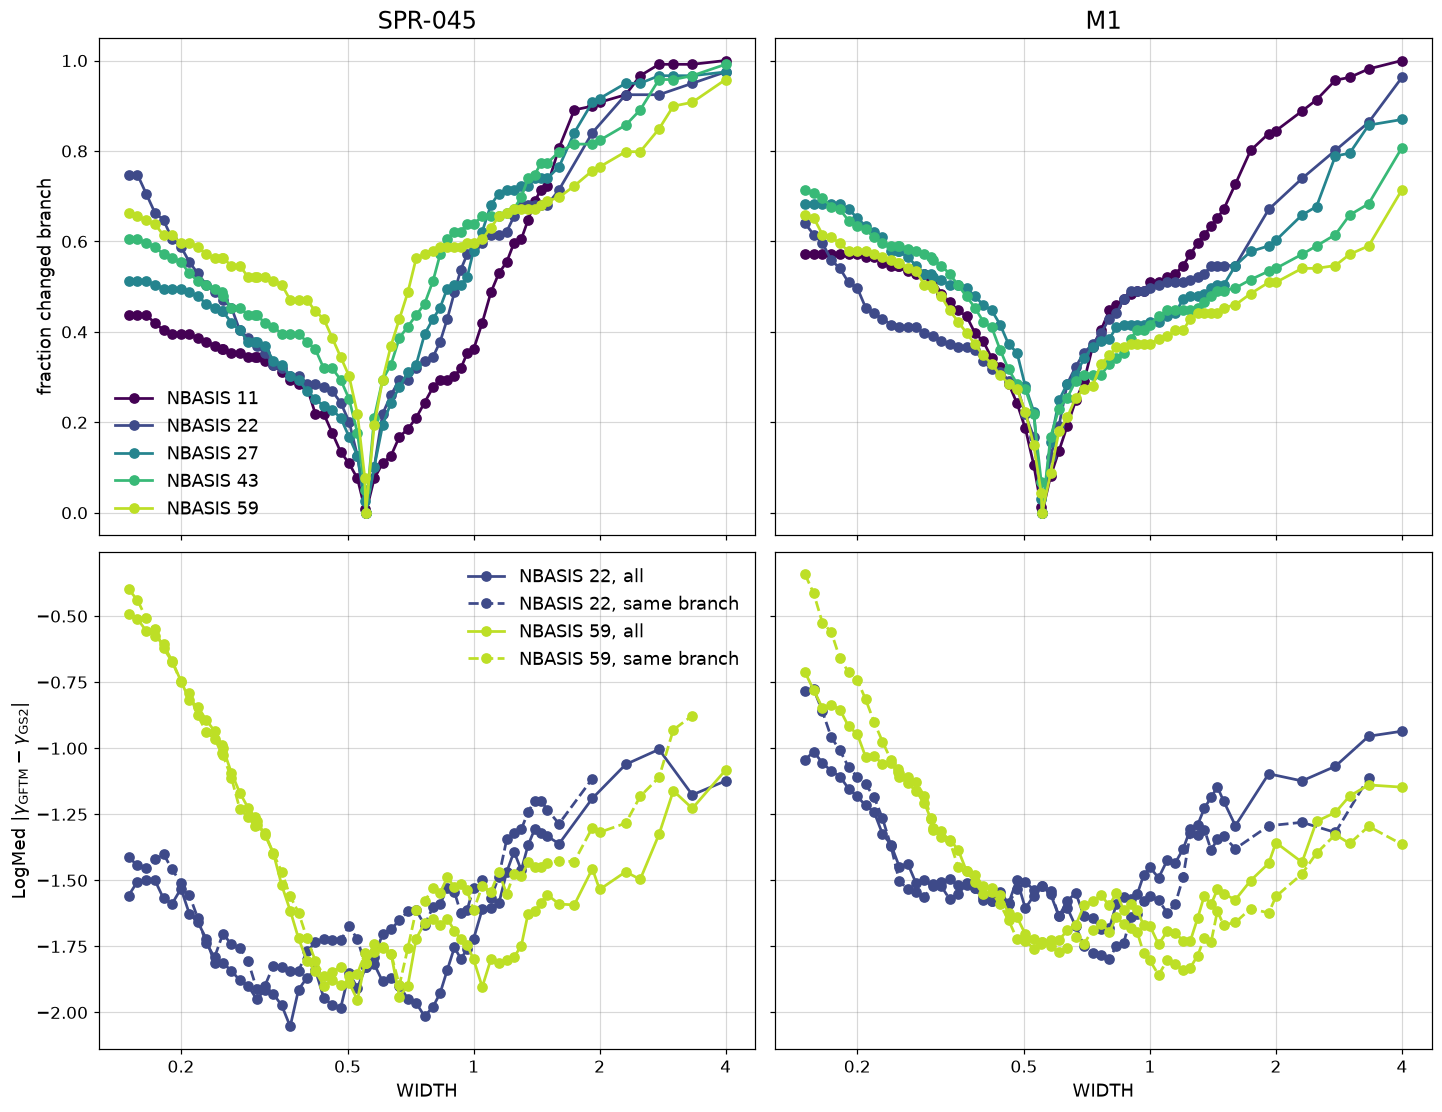

In [5]:
cols = dict(zip(sections, plt.cm.viridis(np.linspace(0, 0.9, len(sections)))))


def sec_rows(db, nb, nx):
    return summary[(summary.db == db) & (summary.nbasis == nb) & (summary.nxgrid == nx)].sort_values("W")


fig_a, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey="row")
for c, db in enumerate(cases):
    for nb, nx in sections.items():
        s = sec_rows(db, nb, nx)
        axes[0, c].plot(s.W, s.frac_change, color=cols[nb], label=f"NBASIS {nb}")
    for nb in (22, 59):
        s = sec_rows(db, nb, sections[nb])
        axes[1, c].plot(s.W, s.logmed_all, color=cols[nb], label=f"NBASIS {nb}, all")
        axes[1, c].plot(s.W, s.logmed_same, color=cols[nb], ls="--", label=f"NBASIS {nb}, same branch")
    axes[0, c].set_title(db, fontsize=fs_title)
    axes[1, c].set(xscale="log", xlabel="WIDTH")
    log_xticks(axes[1, c])
axes[0, 0].set_ylabel("fraction changed branch")
axes[1, 0].set_ylabel(GAMMA_ERR)
axes[0, 0].legend(fontsize=fs_legend)
axes[1, 0].legend(fontsize=fs_legend)
plt.show()

## (b) H1: is the error carried by weight beyond |θ| = π?

Top: LogMed γ error vs WIDTH for cases whose dominant GFTM φ has ≤ 5% (solid) or > 5% (dashed) of |φ|² beyond |θ| = π, at
NBASIS 22 and the top dense section NBASIS 59 / NXGRID 65 (points with < 10 cases are dropped). Bottom: median fraction beyond π
(clipped at 1e-4: at small WIDTH GFTM's Gaussian envelope puts ~nothing there); grey dotted = GS2's median.

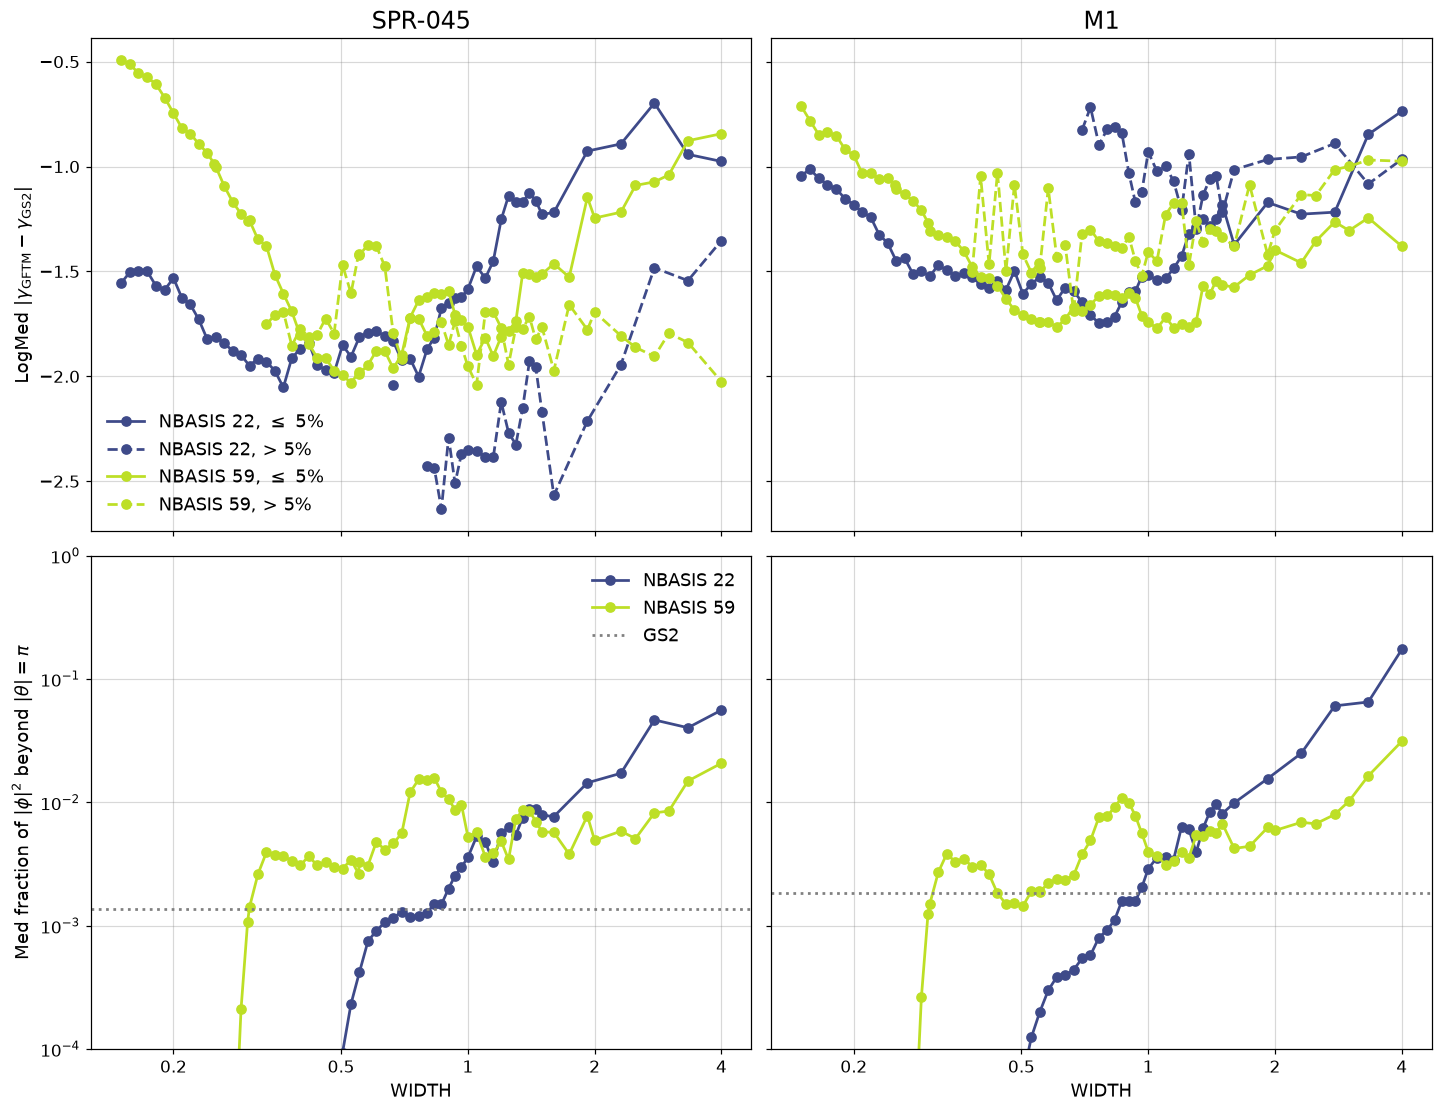

In [6]:
fig_b, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey="row")
for c, db in enumerate(cases):
    for nb in (22, 59):
        s = sec_rows(db, nb, sections[nb])
        axes[0, c].plot(s.W, s.logmed_lo, color=cols[nb], label=rf"NBASIS {nb}, $\leq$ 5%")
        axes[0, c].plot(s.W, s.logmed_hi, color=cols[nb], ls="--", label=f"NBASIS {nb}, > 5%")
        axes[1, c].plot(s.W, s.med_fpi, color=cols[nb], label=f"NBASIS {nb}")
    axes[1, c].axhline(np.median(gs2[db]["fpi"]), color="0.5", ls=":", marker="", label="GS2")
    axes[0, c].set_title(db, fontsize=fs_title)
    axes[1, c].set(xscale="log", yscale="log", xlabel="WIDTH", ylim=(1e-4, 1))
    log_xticks(axes[1, c])
axes[0, 0].set_ylabel(GAMMA_ERR)
axes[1, 0].set_ylabel(r"Med fraction of $|\phi|^2$ beyond $|\theta|=\pi$")
axes[0, 0].legend(fontsize=fs_legend)
axes[1, 0].legend(fontsize=fs_legend)
plt.show()

## (c) H4: does TGLF's γ error rise with WIDTH the same way?

TGLF `wo_fp2p0_<W>` leaves (38e9.4: FILTER 2, NBASIS_MAX 4, NXGRID 16, FIND_WIDTH F, 24 widths), dominant mode, same GS2-KBM cases.
Beside GFTM at NBASIS 22 and 59 (FILTER 0.5). TGLF is the control: no selection is made on it.

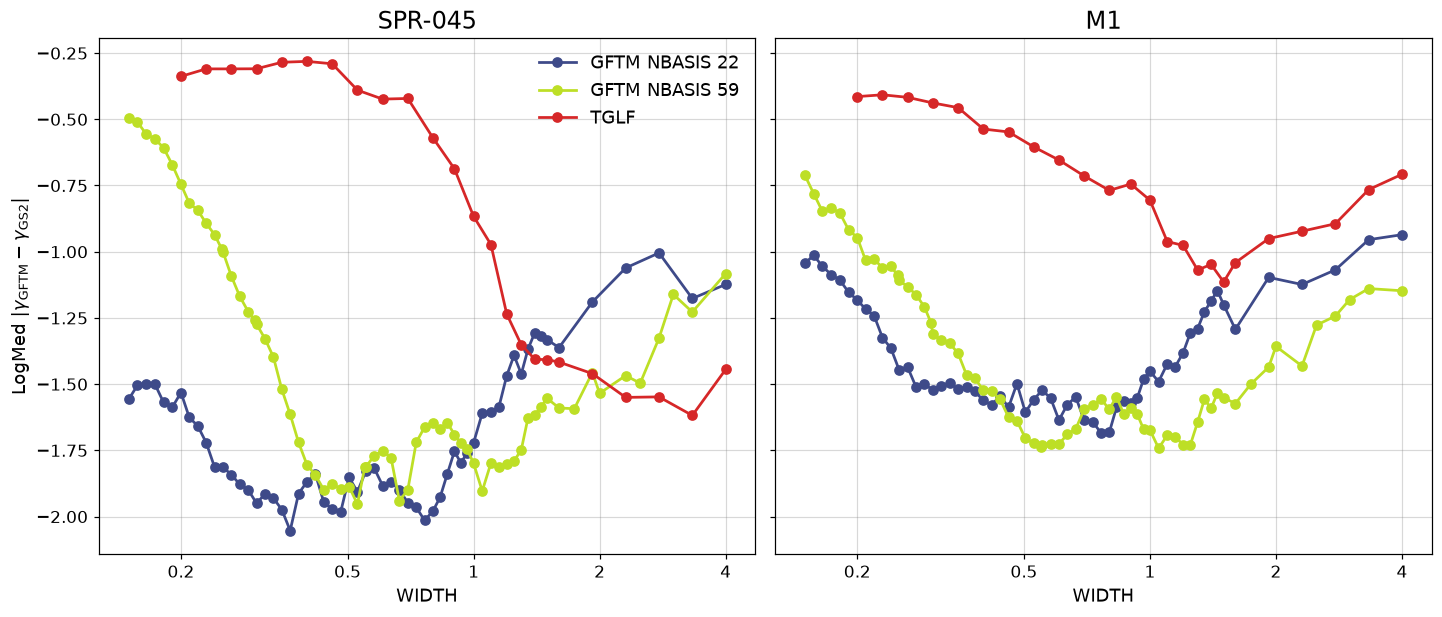

SPR-045 | TGLF LogMed min -1.618 at W 3.3302 | at W 4: -1.445 | GFTM NBASIS 22 min -2.053 at W 0.3647 | at W 4: -1.124
M1 | TGLF LogMed min -1.114 at W 1.5 | at W 4: -0.708 | GFTM NBASIS 22 min -1.684 at W 0.7639 | at W 4: -0.936


In [7]:
tglf = {}
for db in cases:
    for p in sorted((data_root / "TGLF" / "Runs" / "kbm_tglf_filter" / db).glob("wo_fp2p0_w*")):
        nc = p / "pyroscan_tearing.nc" if (p / "pyroscan_tearing.nc").is_file() else p / "pyroscan.nc"
        d = PyroScanGKOutput.from_netcdf(nc).data
        d = d.isel(kx=0, drop=True) if "kx" in d.dims else d
        idx = pd.Index(d.sample_name.values.astype(str)).get_indexer(gs2[db]["names"])
        assert (idx >= 0).all() and str(d.growth_rate.data.units) == gs2[db]["units"]
        g = mag(d.growth_rate.transpose("sample", "mode"))[idx]
        g = np.where(np.isfinite(g) & (g > 0), g, 0.0).max(1)
        tglf[db, float(p.name[10:].replace("p", "."))] = np.log10(np.median(np.abs(g - gs2[db]["gamma"])))
tglf = pd.Series(tglf).rename_axis(["db", "W"]).rename("logmed").reset_index()

fig_c, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for c, db in enumerate(cases):
    for nb in (22, 59):
        s = sec_rows(db, nb, sections[nb])
        axes[c].plot(s.W, s.logmed_all, color=cols[nb], label=f"GFTM NBASIS {nb}")
    t = tglf[tglf.db == db]
    axes[c].plot(t.W, t.logmed, color="C3", label="TGLF")
    axes[c].set(xscale="log", xlabel="WIDTH")
    axes[c].set_title(db, fontsize=fs_title)
    log_xticks(axes[c])
axes[0].set_ylabel(GAMMA_ERR)
axes[0].legend(fontsize=fs_legend)
plt.show()
for db in cases:
    t = tglf[tglf.db == db].set_index("W").logmed
    s = sec_rows(db, 22, 28).set_index("W").logmed_all
    print(db, "| TGLF LogMed min", round(t.min(), 3), "at W", t.idxmin(), "| at W 4:", round(t[4.0], 3),
          "| GFTM NBASIS 22 min", round(s.min(), 3), "at W", s.idxmin(), "| at W 4:", round(s[4.0], 3))

## (d) WIDTH 0.2: does the NBASIS 22 / NXGRID 28 anomaly follow NBASIS or NXGRID?

In [8]:
cells = [(22, 28), (22, 33), (27, 28), (27, 33), (11, 17), (43, 49), (59, 65)]
d02 = summary[(summary.W == 0.2) & summary.apply(lambda r: (r.nbasis, r.nxgrid) in cells, axis=1)]
print(d02[["db", "nbasis", "nxgrid", "n", "med_ratio", "frac_over2", "logmed_all", "frac_gs2_branch", "ref_gs2_branch"]].round(3).to_string(index=False))

     db  nbasis  nxgrid   n  med_ratio  frac_over2  logmed_all  frac_gs2_branch  ref_gs2_branch
SPR-045      11      17 119     14.358       0.933      -0.067            0.160           0.252
SPR-045      22      28 119      0.632       0.126      -1.532            0.143           0.546
SPR-045      22      33 119      0.633       0.126      -1.532            0.143           0.143
SPR-045      27      28 119      7.751       0.807      -0.377            0.218           0.218
SPR-045      27      33 119      7.747       0.807      -0.377            0.218           0.395
SPR-045      43      49 119      3.971       0.748      -0.566            0.261           0.513
SPR-045      59      65 119      2.751       0.664      -0.746            0.244           0.487
     M1      11      17 161      3.988       0.807      -0.111            0.211           0.478
     M1      22      28 161      0.956       0.186      -1.183            0.497           0.727
     M1      22      33 161      0.957  

In [9]:
out = ROOT / "Plots" / analysis_name
out.mkdir(parents=True, exist_ok=True)
for name, fig in (("fig_a_branch_vs_width", fig_a), ("fig_b_beyond_pi_vs_width", fig_b), ("fig_c_tglf_control", fig_c)):
    fig.savefig(out / f"{name}.png", bbox_inches="tight")
summary.round(4).to_csv(out / "leaf_summary.csv", index=False)   # one row per leaf: medians and fractions, no per-case rows
tglf.round(4).to_csv(out / "tglf_control.csv", index=False)
print(sorted(p.name for p in out.iterdir()))

['fig_a_branch_vs_width.png', 'fig_b_beyond_pi_vs_width.png', 'fig_c_tglf_control.png', 'leaf_summary.csv', 'tglf_control.csv']
